Analyzing a dataset of 442 diabetes patients including their age, sex, BMI, blood pressure, blood serum, and disease progression (target) to determine which features track progression the most, if progression differs by BMI group, and if progression differs by sex.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

d = load_diabetes(as_frame=True)
df = d.frame

In [8]:
import os
os.makedirs("figures", exist_ok=True)

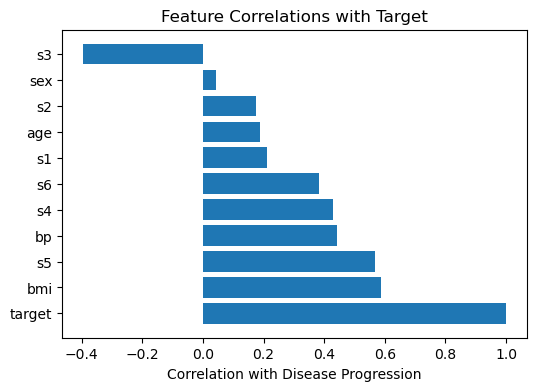

In [9]:
corrs = df.corr()["target"].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(corrs.index, corrs.values)
ax.set_xlabel("Correlation with Disease Progression")
ax.set_title("Feature Correlations with Target")
fig.savefig("figures/features_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

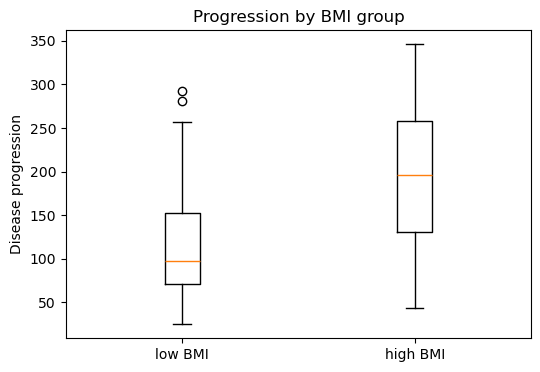

219


In [12]:
df["high_bmi"] = df["bmi"] > df["bmi"].median()
low  = df[~df["high_bmi"]]["target"]
high = df[df["high_bmi"]]["target"]
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([low, high], tick_labels=["low BMI", "high BMI"])   # older matplotlib: labels=
ax.set_ylabel("Disease progression")
ax.set_title("Progression by BMI group")
fig.savefig("figures/progression_by_BMI.png", dpi=150, bbox_inches="tight")
plt.show()
print(df["high_bmi"].sum())

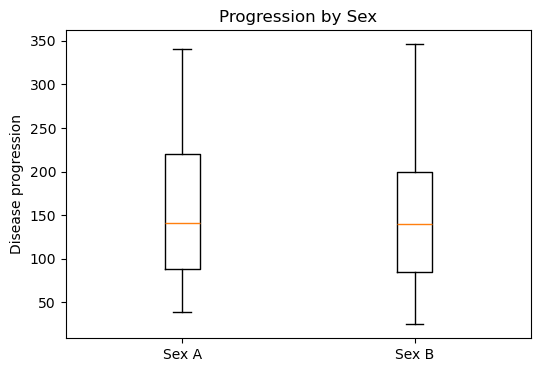

In [11]:
A = df[df["sex"] > 0]["target"]
B = df[df["sex"] < 0]["target"]
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([A, B], tick_labels=["Sex A", "Sex B"])
ax.set_ylabel("Disease progression")
ax.set_title("Progression by Sex")
fig.savefig("figures/progression_by_sex.png", dpi=150, bbox_inches="tight")
plt.show()

The data shows that BMI and s5 have the highest impact on disease progression, age and sex have a lower impact, and s3 is the only feature to be negatively correlated with disease progression. The cohort with high BMI had much higher rates of disease progression than those with low BMI. Although the data does not specify which sex corrosponds to the normalized numbers, sex A had marginally higher one-year disease progression.